In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


In [2]:
feat_con = duckdb.connect(database=":memory:")

In [3]:
dpbl_df = pd.read_csv('data/duckdb_cleaned_dblp_v2.csv')
train_df = pd.read_csv('data/train.csv', index_col=0)

In [4]:
dpbl_df.shape, train_df.shape

((17165, 11), (7972, 4))

In [5]:
dpbl_df.head(5)

,pauthor,ptitle,pyear,pid,pkey,journal,journalfull,booktitle,booktitlefull,journal_abbreviation,ptype
0,jorge semião|juan j. rodríguez-andina|fabian v...,improving the tolerance of pipeline based circ...,2007,180843,conf/dft/SemiaoRVSTT07,NaN,NaN,dft,dft,NaN,inproceedings
1,patrice caire,a normative multi-agent systems approach to th...,2007,162991,conf/dagstuhl/Caire07,NaN,NaN,normative multi agent systems,european grid conference,NaN,inproceedings
2,sundeep b|andrew thangaraj,self-orthogonality of q-ary images of qm-ary c...,2007,2261406,journals/tit/BT07,ieee transactions on information theory,international journal of ambient computing and...,wimob,acm symposium on parallel algorithms and archi...,ijaci,article
3,gerardo pardo-castellote,omg data-distribution service: architectural o...,2003,349720,conf/icdcsw/Pardo-Castellote03,NaN,NaN,icdcs workshops,international agent technology conference,monet,inproceedings
4,ki-hoon lee|kyu-young whang|wook-shin han|min-...,structural consistency: enabling xml keyword s...,2009,1922328,journals/corr/abs-0911-4329,corr,international journal of wireless information ...,NaN,NaN,NaN,article


In [7]:
train_df.head(5)

,key1,key2,label,partition
0,conf/prib/AhmedF07,journals/jcc/PatraS09,False,7
1,conf/vlsid/ChenCC95,journals/tcad/LuoCWCCW08,True,4
2,conf/prozess/Sun88,conf/isnn/SunZLCS07,True,8
3,conf/pricai/BeaumontTSM04,conf/icip/SattarAS08,False,5
4,conf/dft/SemiaoRVSTT07,conf/iolts/Rodriguez-IragoAVSTT05,True,7


In [8]:
# To fix problem with reshuffling that occurs in duckdb: before registering train_duck in DuckDB, add row order in pandas
train_df["_row_id"] = np.arange(len(train_df))
feat_con.register("train_duck", train_df)

In [9]:
feat_con.query("""SELECT * FROM train_duck LIMIT 5""").show()

┌───────────────────────────┬───────────────────────────────────┬─────────┬───────────┬─────────┐
│           key1            │               key2                │  label  │ partition │ _row_id │
│          varchar          │              varchar              │ boolean │   int64   │  int64  │
├───────────────────────────┼───────────────────────────────────┼─────────┼───────────┼─────────┤
│ conf/prib/AhmedF07        │ journals/jcc/PatraS09             │ false   │         7 │       0 │
│ conf/vlsid/ChenCC95       │ journals/tcad/LuoCWCCW08          │ true    │         4 │       1 │
│ conf/prozess/Sun88        │ conf/isnn/SunZLCS07               │ true    │         8 │       2 │
│ conf/pricai/BeaumontTSM04 │ conf/icip/SattarAS08              │ false   │         5 │       3 │
│ conf/dft/SemiaoRVSTT07    │ conf/iolts/Rodriguez-IragoAVSTT05 │ true    │         7 │       4 │
└───────────────────────────┴───────────────────────────────────┴─────────┴───────────┴─────────┘



In [10]:
feat_con.register("dpbl_duck", dpbl_df)

In [11]:
feat_con.query("""SELECT * FROM dpbl_duck LIMIT 5""").show()

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────┬───────┬─────────┬────────────────────────────────┬─────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────┬───────────────────────────────┬────────────────────────────────────────────────────────┬──────────────────────┬───────────────┐
│                                                        pauthor                                                        │                                             ptitle                                             │ pyear │   pid   │              pkey              │                 journal                 │                             journalfull                             │           booktitle           │                     booktitlefull                      │ journal_abbreviatio

In [12]:
# How many train rows have no match in dpbl_duck?
feat_con.query("""
    SELECT 
        COUNT(*) AS total,
        COUNT(d1.pkey) AS matched_key1,
        COUNT(d2.pkey) AS matched_key2,
        COUNT(*) - COUNT(d1.pkey) AS unmatched_key1,
        COUNT(*) - COUNT(d2.pkey) AS unmatched_key2
    FROM train_duck t
    LEFT JOIN dpbl_duck d1 ON t.key1 = d1.pkey
    LEFT JOIN dpbl_duck d2 ON t.key2 = d2.pkey
""").show()

┌───────┬──────────────┬──────────────┬────────────────┬────────────────┐
│ total │ matched_key1 │ matched_key2 │ unmatched_key1 │ unmatched_key2 │
│ int64 │    int64     │    int64     │     int64      │     int64      │
├───────┼──────────────┼──────────────┼────────────────┼────────────────┤
│  7972 │         7972 │         7972 │              0 │              0 │
└───────┴──────────────┴──────────────┴────────────────┴────────────────┘



## JOIN

In [13]:
# add _row_id to SELECT and ORDER BY at the end of the query
feat_con.query("""CREATE OR REPLACE TABLE train_pairs AS
        SELECT t.*,
        t._row_id, 
        d1.pauthor AS pauthor_1,
        d1.ptitle AS ptitle_1,
        d1.pyear AS pyear_1,
        d1.ptype AS ptype_1,
        d1.journal AS journal_1,
        d1.journalfull AS journalfull_1,
        d1.booktitle AS booktitle_1,
        d1.booktitlefull AS booktitlefull_1,
            
        d2.pauthor AS pauthor_2,
        d2.ptitle AS ptitle_2,
        d2.pyear AS pyear_2,
        d2.ptype AS ptype_2,
        d2.journal AS journal_2,
        d2.journalfull AS journalfull_2,
        d2.booktitle AS booktitle_2,
        d2.booktitlefull AS booktitlefull_2
        FROM train_duck t
        LEFT JOIN dpbl_duck d1 ON t.key1 = d1.pkey
        LEFT JOIN dpbl_duck d2 ON t.key2 = d2.pkey
        ORDER BY t._row_id      
""")

In [14]:
feat_con.query("""SELECT * FROM train_pairs LIMIT 10""").show()

┌───────────────────────────┬───────────────────────────────────┬─────────┬───────────┬─────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬─────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────┬───────────────────────────────┬─────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬───────────────────────────────────────────────────────┬────────────────────────┬─────────────┬───

## Feature Engineering with DuckDB

Calulating Author Jaccard
Comparing the Year (year Difference)
Comparing the venues from the key
Comparing the key prefix (also from the key)
Checking for matching - booktitles, booktitlefull, journal, journalfull, and publication type

In [ ]:
feat_con.sql("""
CREATE OR REPLACE TABLE train_features AS

WITH exploded AS (
    SELECT 
        key1, key2,
        UNNEST(STRING_SPLIT(COALESCE(pauthor_1, ''), '|')) AS author1,
        UNNEST(STRING_SPLIT(COALESCE(pauthor_2, ''), '|')) AS author2
    FROM train_pairs
),

intersection_counts AS (
    SELECT 
        key1, key2,
        COUNT(DISTINCT author1) AS intersection_size
    FROM exploded
    WHERE author1 = author2 AND author1 != ''
    GROUP BY key1, key2
),

union_counts AS (
    SELECT 
        key1, key2,
        COUNT(DISTINCT author) AS union_size
    FROM (
        SELECT key1, key2, UNNEST(STRING_SPLIT(COALESCE(pauthor_1, ''), '|')) AS author FROM train_pairs
        UNION
        SELECT key1, key2, UNNEST(STRING_SPLIT(COALESCE(pauthor_2, ''), '|')) AS author FROM train_pairs
    )
    WHERE author != ''
    GROUP BY key1, key2
)

SELECT 
    t.*,

    -- Author Jaccard
    COALESCE(i.intersection_size * 1.0 / NULLIF(u.union_size, 0), 0) AS author_jaccard,

    -- Year difference (NULL-safe)
    CASE 
        WHEN pyear_1 IS NULL OR pyear_2 IS NULL THEN 0
        ELSE ABS(pyear_1 - pyear_2)
    END AS year_diff,
             
    -- Venue from key structure
    SPLIT_PART(t.key1, '/', 2) AS venue_1,
    SPLIT_PART(t.key2, '/', 2) AS venue_2,
    CASE 
        WHEN SPLIT_PART(t.key1, '/', 2) = SPLIT_PART(t.key2, '/', 2) THEN 1 
        ELSE 0 
    END AS venue_match,

    -- Same prefix
    CASE 
        WHEN SPLIT_PART(t.key1, '/', 1) = SPLIT_PART(t.key2, '/', 1) THEN 1 
        ELSE 0 
    END AS same_prefix,
    
    -- Same prefix and venue
    CASE 
    WHEN SPLIT_PART(t.key1, '/', 1) || '/' || SPLIT_PART(t.key1, '/', 2) =
         SPLIT_PART(t.key2, '/', 1) || '/' || SPLIT_PART(t.key2, '/', 2) THEN 1 
    ELSE 0 
    END AS prefix_venue_match,

    -- Same journal
    CASE 
        WHEN journal_1 IS NOT NULL AND journal_1 = journal_2 THEN 1 
        ELSE 0 
    END AS same_journal,
             
    -- Same journal full
    CASE 
        WHEN journalfull_1 IS NOT NULL AND journalfull_1 = journalfull_2 THEN 1 
        ELSE 0 
    END AS same_journal_full,

    -- Same booktitle
    CASE 
        WHEN booktitle_1 IS NOT NULL AND booktitle_1 = booktitle_2 THEN 1 
        ELSE 0 
    END AS same_booktitle,
    
    -- Same booktitle full
    CASE 
        WHEN booktitlefull_1 IS NOT NULL AND booktitlefull_1 = booktitlefull_2 THEN 1 
        ELSE 0 
    END AS same_booktitle_full,

    -- Same publication type
    CASE 
        WHEN ptype_1 IS NOT NULL AND ptype_1 = ptype_2 THEN 1 
        ELSE 0 
    END AS same_ptype

FROM train_pairs t
LEFT JOIN intersection_counts i USING (key1, key2)
LEFT JOIN union_counts u USING (key1, key2)
ORDER BY t._row_id; 
""")

### Without Author and Title Similarity (will be done later in pandas)

In [58]:
feat_con.sql("""
CREATE OR REPLACE TABLE train_features AS
SELECT 
    t.*,
    -- Year difference (NULL-safe)
    CASE 
        WHEN pyear_1 IS NULL OR pyear_2 IS NULL THEN 0
        ELSE ABS(pyear_1 - pyear_2)
    END AS year_diff,
             
    -- Venue from key structure
    SPLIT_PART(t.key1, '/', 2) AS venue_1,
    SPLIT_PART(t.key2, '/', 2) AS venue_2,
    CASE 
        WHEN SPLIT_PART(t.key1, '/', 2) = SPLIT_PART(t.key2, '/', 2) THEN 1 
        ELSE 0 
    END AS venue_match,

    -- Same prefix
    CASE 
        WHEN SPLIT_PART(t.key1, '/', 1) = SPLIT_PART(t.key2, '/', 1) THEN 1 
        ELSE 0 
    END AS same_prefix,
    
    -- Same prefix and venue
    CASE 
        WHEN SPLIT_PART(t.key1, '/', 1) || '/' || SPLIT_PART(t.key1, '/', 2) =
             SPLIT_PART(t.key2, '/', 1) || '/' || SPLIT_PART(t.key2, '/', 2) THEN 1 
        ELSE 0 
    END AS prefix_venue_match,

    -- Same journal
    CASE 
        WHEN journal_1 IS NOT NULL AND journal_1 = journal_2 THEN 1 
        ELSE 0 
    END AS same_journal,
             
    -- Same journal full
    CASE 
        WHEN journalfull_1 IS NOT NULL AND journalfull_1 = journalfull_2 THEN 1 
        ELSE 0 
    END AS same_journal_full,

    -- Same booktitle
    CASE 
        WHEN booktitle_1 IS NOT NULL AND booktitle_1 = booktitle_2 THEN 1 
        ELSE 0 
    END AS same_booktitle,
    
    -- Same booktitle full
    CASE 
        WHEN booktitlefull_1 IS NOT NULL AND booktitlefull_1 = booktitlefull_2 THEN 1 
        ELSE 0 
    END AS same_booktitle_full,

    -- Same publication type
    CASE 
        WHEN ptype_1 IS NOT NULL AND ptype_1 = ptype_2 THEN 1 
        ELSE 0 
    END AS same_ptype

FROM train_pairs t
ORDER BY t._row_id; 
""")

### Overview of Features

In [59]:
feat_con.query("SELECT * FROM train_features").show()

┌──────────────────────────────┬───────────────────────────────────┬─────────┬───────────┬─────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬──────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────┬───────────────────────────────┬─────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬───────────────────────────────────────────────────────┬──────────────────────────────────────

474 rows where the venue matches and the label is true

In [60]:
feat_con.query("SELECT key1, key2, label, venue_match FROM train_features WHERE venue_match = 1 AND label = 'true'").show()

┌─────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────┬─────────┬─────────────┐
│                                      key1                                       │                                   key2                                    │  label  │ venue_match │
│                                     varchar                                     │                                  varchar                                  │ boolean │    int32    │
├─────────────────────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┼─────────┼─────────────┤
│ conf/gil/KustermannSAH08                                                        │ conf/gil/PremWRH06                                                        │ true    │           1 │
│ journals/ijbc/BrugioniHMB07                                                   

2505 rows where the label is true and the key prefixes match

In [61]:
feat_con.query("SELECT key1, key2, label, same_prefix FROM train_features WHERE same_prefix = 1 AND label = 'true'").show()

┌──────────────────────────────────┬───────────────────────────────────┬─────────┬─────────────┐
│               key1               │               key2                │  label  │ same_prefix │
│             varchar              │              varchar              │ boolean │    int32    │
├──────────────────────────────────┼───────────────────────────────────┼─────────┼─────────────┤
│ conf/prozess/Sun88               │ conf/isnn/SunZLCS07               │ true    │           1 │
│ conf/dft/SemiaoRVSTT07           │ conf/iolts/Rodriguez-IragoAVSTT05 │ true    │           1 │
│ conf/lmo/DemphlousL96            │ conf/reflection/DemphlousL99      │ true    │           1 │
│ conf/mmb/SassJ06                 │ conf/kivs/Sass03                  │ true    │           1 │
│ conf/nems/RaoLW09                │ conf/cars/FuJDCWLGLZDMLHPGCLWCX03 │ true    │           1 │
│ conf/srds/KazemzadehJ09          │ conf/cbms/KazemzadehS06           │ true    │           1 │
│ conf/icdcsw/Pardo-Castellote

470 - prefix and venue as a single feature - match

In [62]:
feat_con.query("SELECT key1, key2, label, prefix_venue_match FROM train_features WHERE prefix_venue_match = 1 AND label = 'true'").show()

┌─────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────┬─────────┬────────────────────┐
│                                      key1                                       │                                   key2                                    │  label  │ prefix_venue_match │
│                                     varchar                                     │                                  varchar                                  │ boolean │       int32        │
├─────────────────────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┼─────────┼────────────────────┤
│ conf/gil/KustermannSAH08                                                        │ conf/gil/PremWRH06                                                        │ true    │                  1 │
│ journals/ijbc/BrugioniHMB07                

In [63]:
train_pairs = feat_con.query("SELECT * FROM train_features").to_df()

In [64]:
train_pairs.columns

Index(['key1', 'key2', 'label', 'partition', '_row_id', '_row_id_1',
       'pauthor_1', 'ptitle_1', 'pyear_1', 'ptype_1', 'journal_1',
       'journalfull_1', 'booktitle_1', 'booktitlefull_1', 'pauthor_2',
       'ptitle_2', 'pyear_2', 'ptype_2', 'journal_2', 'journalfull_2',
       'booktitle_2', 'booktitlefull_2', 'year_diff', 'venue_1', 'venue_2',
       'venue_match', 'same_prefix', 'prefix_venue_match', 'same_journal',
       'same_journal_full', 'same_booktitle', 'same_booktitle_full',
       'same_ptype'],
      dtype='str')

### Applying the title similarity part in pandas

In [65]:
text_cols = ["ptitle_1", "ptitle_2", "pauthor_1", "pauthor_2"]
train_pairs[text_cols] = train_pairs[text_cols].fillna("")

In [66]:
vectorizer = TfidfVectorizer(stop_words="english")

def title_sim(row):
    t1 = str(row["ptitle_1"]).strip()
    t2 = str(row["ptitle_2"]).strip()
    
    if not t1 or not t2:
        return 0.0
    
    try:
        tfidf = vectorizer.fit_transform([t1, t2])
        return cosine_similarity(tfidf[0], tfidf[1])[0][0]
    except ValueError:
        return 0.0

train_pairs["title_sim"] = train_pairs.apply(title_sim, axis=1)

### Author Similarity also with Pandas

In [67]:
def author_jaccard(a1, a2):
    if pd.isna(a1) or pd.isna(a2):
        return 0
    
    s1 = set(a1.split("|"))
    s2 = set(a2.split("|"))
    
    return len(s1 & s2) / len(s1 | s2)

train_pairs["author_jaccard"] = train_pairs.apply(
    lambda x: author_jaccard(x["pauthor_1"], x["pauthor_2"]),
    axis=1
)

In [68]:
train_pairs.columns

Index(['key1', 'key2', 'label', 'partition', '_row_id', '_row_id_1',
       'pauthor_1', 'ptitle_1', 'pyear_1', 'ptype_1', 'journal_1',
       'journalfull_1', 'booktitle_1', 'booktitlefull_1', 'pauthor_2',
       'ptitle_2', 'pyear_2', 'ptype_2', 'journal_2', 'journalfull_2',
       'booktitle_2', 'booktitlefull_2', 'year_diff', 'venue_1', 'venue_2',
       'venue_match', 'same_prefix', 'prefix_venue_match', 'same_journal',
       'same_journal_full', 'same_booktitle', 'same_booktitle_full',
       'same_ptype', 'title_sim', 'author_jaccard'],
      dtype='str')

### Split Data

In [69]:
features = [
    "title_sim",
    "author_jaccard",
    "prefix_venue_match",
    "year_diff",
    "same_journal",
    "same_journal_full",
    "same_booktitle",
    "same_booktitle_full",
    "same_ptype"
]

X = train_pairs[features]
y = train_pairs["label"]

In [70]:
X.isna().sum()

title_sim              0
author_jaccard         0
prefix_venue_match     0
year_diff              0
same_journal           0
same_journal_full      0
same_booktitle         0
same_booktitle_full    0
same_ptype             0
dtype: int64

In [71]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2, # 80/20 split since it is standard
    stratify=y,
    random_state=42
)

## Models

### Logistic regression

In [72]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
preds = model.predict_proba(X_val)[:,1]

print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.8723130073246596
Accuracy: 0.8476489028213167
Precision: 0.9945652173913043
Recall: 0.6958174904942965
F1 Score: 0.8187919463087249


In [74]:
pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

author_jaccard         16.569905
title_sim               6.505225
prefix_venue_match      2.757202
same_booktitle          0.325758
same_journal            0.296266
same_ptype              0.138319
year_diff               0.021906
same_booktitle_full    -0.569396
same_journal_full      -0.811130
dtype: float64

## Decision tree

In [75]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [76]:
from sklearn.metrics import classification_report
pred = dt.predict(X_val)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

       False       0.77      1.00      0.87       806
        True       0.99      0.70      0.82       789

    accuracy                           0.85      1595
   macro avg       0.88      0.85      0.85      1595
weighted avg       0.88      0.85      0.85      1595



## Random forest

In [77]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
preds_rf = rf.predict_proba(X_val)[:, 1]

print("Random Forest Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_rf):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_rf.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_rf.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_rf.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_rf.round()):.4f}")

Random Forest Results:
  ROC AUC:   0.8701
  Accuracy:  0.8376
  Precision: 0.9373
  Recall:    0.7199
  F1 Score:  0.8143


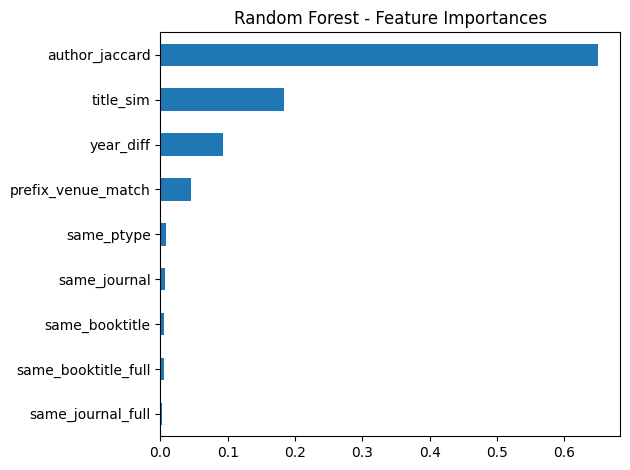

In [79]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

## XGBoost 

In [80]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [81]:
preds_xgb = xgb.predict_proba(X_val)[:, 1]

print("XGBoost Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_xgb):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_xgb.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_xgb.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_xgb.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_xgb.round()):.4f}")

XGBoost Results:
  ROC AUC:   0.8780
  Accuracy:  0.8508
  Precision: 0.9758
  Recall:    0.7161
  F1 Score:  0.8260


same_journal           0.000495
same_journal_full      0.001363
same_ptype             0.002872
same_booktitle_full    0.003310
year_diff              0.004102
same_booktitle         0.004324
title_sim              0.007130
prefix_venue_match     0.038513
author_jaccard         0.937892
dtype: float32


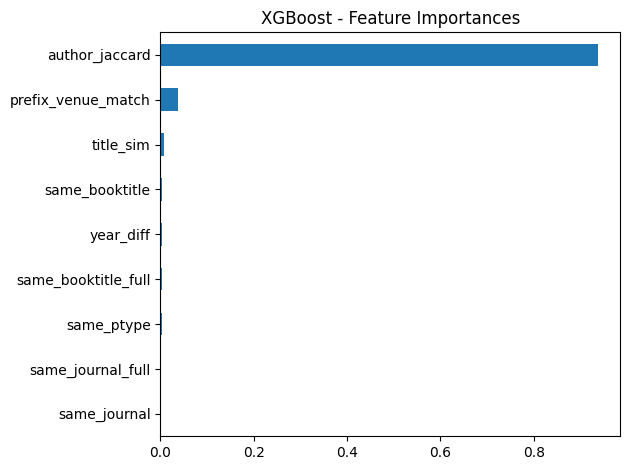

In [82]:
import matplotlib.pyplot as plt
importances_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values()
importances_xgb.plot(kind="barh")
print(importances_xgb)
plt.title("XGBoost - Feature Importances")
plt.tight_layout()
plt.show()